In [2]:
import pandas as pd
import numpy as np

In [3]:
df= pd.read_csv(r'C:\Users\Administrator\Desktop\AI-Portfolio\Deep-Learning\creditcard.csv')

In [52]:
df.shape

(284807, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
from sklearn.tree import DecisionTreeClassifier
model= DecisionTreeClassifier()
X=df.drop('Class', axis= 1)
Y= df['Class']

model.fit(X,Y)
importance=pd.Series(model.feature_importances_, index= X.columns)
importance.sort_values(ascending= False)

V17       0.541302
V14       0.097545
V12       0.044223
V10       0.039758
V27       0.038096
V23       0.020240
V26       0.018166
V16       0.017644
V21       0.017062
V20       0.016842
V28       0.014912
V8        0.012325
V4        0.011582
V1        0.011477
V15       0.011447
V13       0.011200
V11       0.010770
V7        0.009116
V24       0.008933
V6        0.008609
Time      0.007937
V22       0.007474
V19       0.006257
V3        0.005591
V5        0.003894
V25       0.003545
Amount    0.002370
V18       0.001551
V9        0.000131
V2        0.000000
dtype: float64

In [6]:
df.corr()['Class'].sort_values(ascending = False)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

In [7]:
from sklearn.linear_model import Lasso
model=Lasso(alpha= 0.001)
model.fit(X, Y)

importance=pd.Series(model.coef_, index= X.columns)
importance.sort_values(ascending= False)

V11       5.196309e-03
V4        3.278379e-03
V2        2.351736e-03
V19       3.780031e-04
V21       2.763821e-04
V8        8.596331e-05
Amount    5.302697e-06
V28       0.000000e+00
V27       0.000000e+00
V26       0.000000e+00
V25       0.000000e+00
V24      -0.000000e+00
V23       0.000000e+00
V22       0.000000e+00
V20       0.000000e+00
V15      -0.000000e+00
V13      -0.000000e+00
Time     -1.256231e-08
V6       -1.040069e-03
V1       -1.698202e-03
V5       -1.886722e-03
V9       -2.817009e-03
V18      -4.092100e-03
V3       -4.830589e-03
V7       -6.017322e-03
V10      -7.287809e-03
V16      -7.997919e-03
V12      -9.741840e-03
V14      -1.212633e-02
V17      -1.463949e-02
dtype: float64

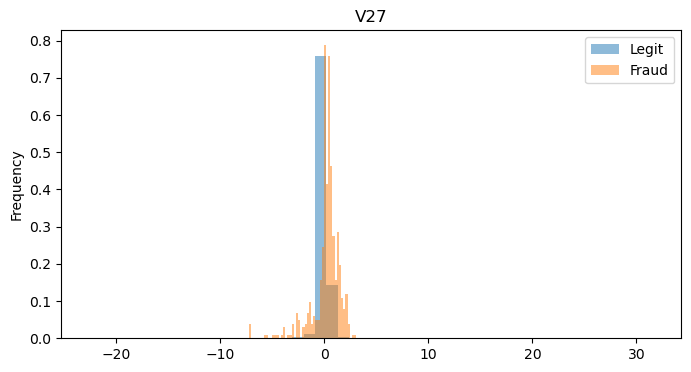

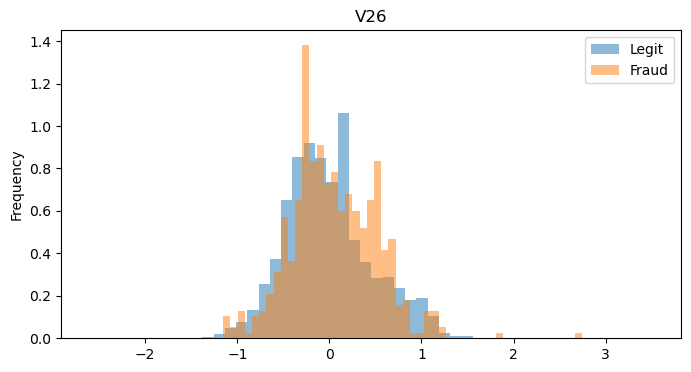

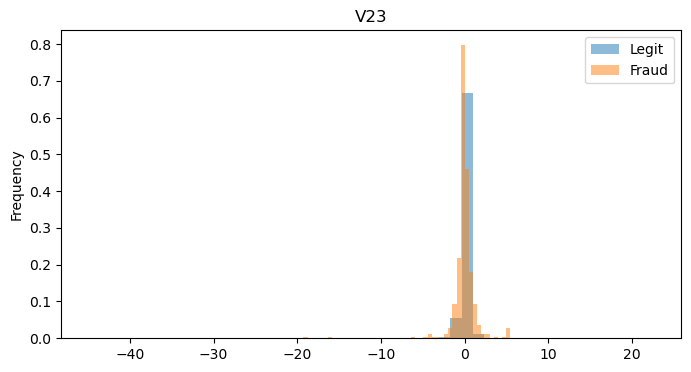

In [8]:
import matplotlib.pyplot as plt

for col in ['V27', 'V26', 'V23']:
    fig, ax = plt.subplots(figsize=(8,4))

    df[df.Class==0][col].plot(
        kind='hist',
        bins=50,
        density=True,
        alpha=0.5,
        label='Legit',
        ax=ax
    )

    df[df.Class==1][col].plot(
        kind='hist',
        bins=50,
        density=True,
        alpha=0.5,
        label='Fraud',
        ax=ax
    )

    ax.legend()
    ax.set_title(col)
    plt.show()

In [5]:
# Consensus feature ranking
high_importance = ['V2', 'V3', 'V4', 'V7', 'V8', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V19', 'V21', 'V27', 'Time', 'Amount']
low_importance = ['V6', 'V13', 'V20', 'V22', 'V23','V24', 'V25', 'V26', 'V28']
medium_importance = ['V1', 'V5', 'V9', 'V18']

In [7]:
import random
import numpy as np
import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [8]:
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from scikeras.wrappers import KerasClassifier

# =========================
# DATA
# =========================

x = df[high_importance + medium_importance]
y = df['Class']

# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# FEATURE TRANSFORMATION
# =========================

X_train = X_train.copy()
X_test = X_test.copy()

X_train['Time'] = X_train['Time'] / 3600
X_test['Time'] = X_test['Time'] / 3600

X_train['Amount'] = np.log1p(X_train['Amount'])
X_test['Amount'] = np.log1p(X_test['Amount'])

# =========================
# STANDARD SCALING
# =========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# CLASS WEIGHTS
# =========================

# class_weights = compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(y_train),
#     y=y_train
# )

# class_weights = dict(enumerate(class_weights))

# print("Class Weights:", class_weights)

# =========================
# MODEL FUNCTION
# =========================

def create_model():

    model = Sequential([
        tf.keras.Input(shape=(X_train_scaled.shape[1],)),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dropout(0.3),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='AUC'),
            tf.keras.metrics.Recall(name='Recall'),
            tf.keras.metrics.Precision(name='Precision')
        ]
    )

    return model

# =========================
# EARLY STOPPING
# =========================

early_stop = EarlyStopping(
    monitor='val_AUC',
    mode= 'max',
    patience=6,
    restore_best_weights=True
)

# =========================
# SCIKERAS WRAPPER
# =========================

model = KerasClassifier(
    model=create_model,
    optimizer= 'adam',
    loss="binary_crossentropy",
    epochs=40,
    batch_size=1048,
    verbose=1,
    callbacks=[early_stop],
    class_weight= {0: 1, 1: 150},
    validation_split=0.2
)

# =========================
# TRAIN MODEL
# =========================

model.fit(X_train_scaled, y_train)

Epoch 1/40
174/174 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - AUC: 0.8348 - Precision: 0.0087 - Recall: 0.7170 - loss: 0.5881 - val_AUC: 0.9334 - val_Precision: 0.8481 - val_Recall: 0.8072 - val_loss: 0.2478
Epoch 2/40
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - AUC: 0.9350 - Precision: 0.1879 - Recall: 0.7910 - loss: 0.2510 - val_AUC: 0.9635 - val_Precision: 0.2652 - val_Recall: 0.8434 - val_loss: 0.1593
Epoch 3/40
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.9622 - Precision: 0.1259 - Recall: 0.8457 - loss: 0.1763 - val_AUC: 0.9689 - val_Precision: 0.1796 - val_Recall: 0.8675 - val_loss: 0.1455
Epoch 4/40
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.9677 - Precision: 0.1231 - Recall: 0.8392 - loss: 0.1654 - val_AUC: 0.9740 - val_Precision: 0.1648 - val_Recall: 0.8795 - val_loss: 0.1390
Epoch 5/40
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.9718 - Precision: 0.1293 - Recall: 0.8875 - loss: 0.1480 - val_AUC: 0.9769 - val_Precision: 0.1900 - val_Recall: 0.8675 - val_loss: 0.138

,model,<function cre...00123C9BB36A0>
,build_fn,None
,warm_start,False
,random_state,None
,optimizer,'adam'
,loss,'binary_crossentropy'
,metrics,None
,batch_size,1048
,validation_batch_size,None
,verbose,1
,callbacks,[<keras.src.ca...00123E16E82F0>]


In [106]:
pred = model.predict_proba(X_test_scaled)[:, 1]

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [115]:
y_pred= (pred > 0.5).astype(int)

In [116]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, pred))


Accuracy: 0.9943119974719988
Precision: 0.2202970297029703
Recall: 0.9081632653061225
F1 Score: 0.3545816733067729
Confusion Matrix:
 [[56549   315]
 [    9    89]]
AUC Score: 0.9711710109620664


In [31]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# 1. Define the CV Strategy 
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Build a Leakage-Proof Pipeline
# Note: We pass raw unscaled 'X_train' into this pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Fits/Scales strictly within fold boundaries
    ('mlp', model)                 # Your Scikeras Classifier wrapper
])

print("Running Leakage-Proof Cross-Validation...")

# 3. Generate clean out-of-fold probability predictions
y_probabs_clean = cross_val_predict(
    pipeline, 
    X_train,                       # <-- Pass unscaled data here
    y_train,
    cv=cv_strategy, 
    method='predict_proba'
)[:, 1]

# 4. Evaluate using your optimized threshold (0.50)
y_preds_clean = (y_probabs_clean >= 0.50).astype(int)

print("\n--- Leakage-Proof CV Metrics (Threshold 0.5) ---")
print("Confusion Matrix:")
print(confusion_matrix(y_train, y_preds_clean))
print("\nClassification Report:")
print(classification_report(y_train, y_preds_clean))
print(f"ROC-AUC Score: {roc_auc_score(y_train, y_probabs_clean):.4f}")

Running Leakage-Proof Cross-Validation...
Epoch 1/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - AUC: 0.4725 - Precision: 0.0897 - Recall: 0.1012 - loss: 1.1238 - val_AUC: 0.8882 - val_Precision: 0.5172 - val_Recall: 0.7627 - val_loss: 0.4123
Epoch 2/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - AUC: 0.8359 - Precision: 0.1721 - Recall: 0.4086 - loss: 0.4964 - val_AUC: 0.9119 - val_Precision: 0.2565 - val_Recall: 0.8305 - val_loss: 0.2964
Epoch 3/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - AUC: 0.9201 - Precision: 0.1318 - Recall: 0.5875 - loss: 0.3575 - val_AUC: 0.9185 - val_Precision: 0.1856 - val_Recall: 0.8305 - val_loss: 0.2428
Epoch 4/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - AUC: 0.9480 - Precision: 0.1196 - Recall: 0.6809 - loss: 0.2735 - val_AUC: 0.9317 - val_Precision: 0.1397 - val_Recall: 0.8475 - val_loss: 0.2043
Epoch 5/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - AUC: 0.9540 - Precision: 0.1095 - Recall: 0.7471 - loss: 0.2450 - val_AUC: 0.9392 - val_Precision: 0.12

In [56]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_train, y_probabs_clean)

# Calculate F1 score for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Optimal Threshold for F1: {best_threshold:.4f}")
print(f"Best Achievable F1-Score: {f1_scores[best_idx]:.4f}")

Optimal Threshold for F1: 0.7994
Best Achievable F1-Score: 0.6804


In [57]:
y_preds_clean = (y_probabs_clean >= 0.80).astype(int)

print(confusion_matrix(y_train, y_preds_clean))
print("Accuracy:", accuracy_score(y_train, y_preds_clean))
print("Precision:", precision_score(y_train, y_preds_clean))
print("Recall:", recall_score(y_train, y_preds_clean))
print("F1 Score:", f1_score(y_train, y_preds_clean))
print(f"ROC-AUC Score: {roc_auc_score(y_train, y_probabs_clean):.4f}")

[[227397     54]
 [   164    230]]
Accuracy: 0.9990432091992363
Precision: 0.8098591549295775
Recall: 0.583756345177665
F1 Score: 0.6784660766961652
ROC-AUC Score: 0.9330


In [113]:
pred1 = model.predict_proba(X_test_scaled)[:, 1]
y_pred1= (pred1 > 0.80).astype(int)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [114]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred1))
print("Precision:", precision_score(y_test, y_pred1))
print("Recall:", recall_score(y_test, y_pred1))
print("F1 Score:", f1_score(y_test, y_pred1))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred1))
print("AUC Score:", roc_auc_score(y_test, pred1))


Accuracy: 0.9979986657771848
Precision: 0.45698924731182794
Recall: 0.8673469387755102
F1 Score: 0.5985915492957746
Confusion Matrix:
 [[56763   101]
 [   13    85]]
AUC Score: 0.9711710109620664


In [70]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid
# Prefix parameters with 'mlp__' to tell the Pipeline to pass them to the Keras model
param_grid = {
    'mlp__batch_size': [1024, 2048, 4096],
    'mlp__epochs': [30, 50],
    'mlp__class_weight' : [
        {0: 1, 1: 50},
        {0: 1, 1: 100},
        {0: 1, 1: 150},
        {0: 1, 1: 200}
    ]
}

# 2. Set up GridSearchCV
# We use your existing 'pipeline' and 'cv_strategy'
grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=cv_strategy, 
    scoring='f1',        # CRITICAL: Optimize for F1-score, not accuracy
    verbose=2,           # Shows progress output
    n_jobs=-1            # Uses all available CPU cores to speed up training
)

print("Starting Grid Search... This may take a while depending on your hardware.")

# 3. Fit the Grid Search on the UNSCALED training data
# The pipeline will handle the scaling internally for every fold combination
grid_search.fit(X_train, y_train)

# 4. View the results
print("\n--- Grid Search Complete ---")
print(f"Best Parameters found: {grid_search.best_params_}")
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")

# 5. Extract the best performing pipeline
best_pipeline = grid_search.best_estimator_

Starting Grid Search... This may take a while depending on your hardware.
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - AUC: 0.7911 - Precision: 0.0074 - Recall: 0.6752 - loss: 0.5075 - val_AUC: 0.8988 - val_Precision: 0.8590 - val_Recall: 0.8072 - val_loss: 0.1792
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8793 - Precision: 0.4064 - Recall: 0.6913 - loss: 0.1869 - val_AUC: 0.9244 - val_Precision: 0.8481 - val_Recall: 0.8072 - val_loss: 0.0971
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.9225 - Precision: 0.4936 - Recall: 0.7428 - loss: 0.1281 - val_AUC: 0.9451 - val_Precision: 0.7556 - val_Recall: 0.8193 - val_loss: 0.0851
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.9461 - Precision: 0.3783 - Recall: 0.7846 - loss: 0.1013 - val_AUC: 0.9590 - val_Precision: 0.6355 - val_Recall: 0.8193 - val_loss: 0.0797
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.9492 - Preci

In [71]:
# Entire pipeline
print(best_pipeline)

Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 KerasClassifier(batch_size=2048, callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x0000012383815B70>], class_weight={0: 1, 1: 50}, epochs=30, loss='binary_crossentropy', model=<function create_model at 0x00000123C9BB36A0>, optimizer='adam', validation_split=0.2))])


In [73]:
best_model = grid_search.best_estimator_

y_probabs_best = cross_val_predict(
    best_model, 
    X_train, 
    y_train, 
    cv=cv_strategy, 
    method='predict_proba',
    n_jobs=-1
)[:, 1]

In [81]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_train, y_probabs_best)

# Calculate F1 score for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Optimal Threshold for F1: {best_threshold:.4f}")
print(f"Best Achievable F1-Score: {f1_scores[best_idx]:.4f}")

Optimal Threshold for F1: 0.5253
Best Achievable F1-Score: 0.7089


In [85]:
y_pred_best= (y_probabs_best > 0.525).astype(int)

In [86]:
print("Accuracy:", accuracy_score(y_train, y_pred_best))
print("Precision:", precision_score(y_train, y_pred_best))
print("Recall:", recall_score(y_train, y_pred_best))
print("F1 Score:", f1_score(y_train, y_pred_best))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_pred_best))
print("AUC Score:", roc_auc_score(y_train, y_probabs_best))

Accuracy: 0.9989861528670807
Precision: 0.7052896725440806
Recall: 0.7106598984771574
F1 Score: 0.7079646017699115
Confusion Matrix:
 [[227334    117]
 [   114    280]]
AUC Score: 0.8777990716670676


In [117]:
pred_final = best_model.predict_proba(X_test)[:, 1]
y_pred_final= (pred_final > 0.525).astype(int)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [118]:
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("F1 Score:", f1_score(y_test, y_pred_final))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("AUC Score:", roc_auc_score(y_test, pred_final))

Accuracy: 0.9991748885221726
Precision: 0.7684210526315789
Recall: 0.7448979591836735
F1 Score: 0.7564766839378239
Confusion Matrix:
 [[56842    22]
 [   25    73]]
AUC Score: 0.8977903239236042
